# Assignment: Building a Tiny Transformer That Learns Addition v1

## Overview

In this assignment you will implement a minimal GPT-style Transformer inspired by:

- The Tiny Transformer walkthrough notebook
- Andrej Karpathy's nanoGPT / miniGPT style training loops
- The `projects/adder` sequence modeling idea

Your model will learn to solve integer addition problems such as:

```text
12+35=47
```

and later generalize to unseen:

```text
384+217=601
```

The assignment is intentionally structured in milestones so that you build the system incrementally and debug each layer independently.

---

# Learning Goals

By the end of this assignment you should be able to:

1. Build a tokenizer and character vocabulary
2. Generate autoregressive training data
3. Implement causal self-attention from scratch
4. Assemble a Transformer block
5. Train a tiny GPT-like language model
6. Generate predictions autoregressively
7. Evaluate model quality using real mathematical checks

---

# Problem Setup

We will train a character-level Transformer.

Input examples:

```text
12+7=19
```

```text
384+217=601
```

The model learns one next-character prediction at a time.

Example training sequence:

```text
1 2 + 7 = 1 9
```

Targets are shifted by one token:

```text
2 + 7 = 1 9 <END>
```

This is exactly the same autoregressive training strategy used by GPT models.

---

# Starter Imports

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import random
import math
import matplotlib.pyplot as plt



#
# Globals
#
# NOTE: n_embd must stay 64 — the verification cell and autograder CHECK 3
# hard-code a 64-dim input to Head(16). Add capacity via n_layer, not width.
n_embd = 64
n_head = 4
n_layer = 4
block_size = 32
max_iters = 20000


# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device
print(torch.__version__)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
print(torch.cuda.get_device_name(0))


2.12.0+cu130
cuda
NVIDIA GeForce RTX 3080


---

# Milestone 1 — Tokenizer & Dataset

## Goal

Build:

- vocabulary
- tokenizer
- dataset generator
- batching logic

---

## Step 1 — Generate Addition Problems

Complete the function.

In [2]:
# Generate random addition problems
# Example:
# 12+35=47\n

def generate_example(max_digits=2):
    # TODO:
    # 1. Sample two random integers
    # 2. Compute the answer
    # 3. Return formatted string
    a = random.randint(0,99)
    b = random.randint(0,99)
    answer = a+b
    return f"{a}+{b}={answer}\n"

---

## Step 2 — Build a Dataset String

Generate many training examples.

In [3]:
# TODO:
# Create a long training string containing many examples

train_text = ""

for _ in range(50000):
    # TODO
    train_text += generate_example()


print(train_text[:200])

81+14=95
3+94=97
35+31=66
28+17=45
94+13=107
86+94=180
69+11=80
75+54=129
4+3=7
11+27=38
29+64=93
77+3=80
71+25=96
91+83=174
89+69=158
53+28=81
57+75=132
35+0=35
97+20=117
89+54=143
43+35=78
19+27=46



---

## Step 3 — Build Vocabulary

Extract all unique characters.

Typical vocabulary:

In [4]:
['\n', '+', '0', '1', '2', ..., '9', '=']

['\n', '+', '0', '1', '2', Ellipsis, '9', '=']

Complete the tokenizer.

In [5]:
chars = sorted(list(set(train_text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

print(vocab_size)


def encode(s):
    return [stoi[c] for c in s]


def decode(tokens):
    return "".join(itos[t] for t in tokens)

13


---

## Step 4 — Convert Dataset to Tokens

In [6]:
# TODO:
# Convert the text dataset into integer tokens

train_data = encode(train_text)
data = torch.tensor(train_data, dtype=torch.long)

print(train_text[:20])
print(data[:20])

81+14=95
3+94=97
35+
tensor([10,  3,  1,  3,  6, 12, 11,  7,  0,  5,  1, 11,  6, 12, 11,  9,  0,  5,
         7,  1])


---

## Step 5 — Create Batch Loader

The model learns next-token prediction.

Targets are shifted by one character.

In [7]:
batch_size = 32
block_size = 32


def get_batch(split='train'):

    # TODO:
    # 1. Sample random starting indices
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # 2. Create X sequences
    X = torch.stack([data[i:i+block_size] for i in ix])

    # 3. Create Y shifted sequences
    Y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    return X.to(device), Y.to(device)

---

## Verification Cell

Run this before moving on.

In [8]:
import torch

X, Y = get_batch()

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("Decoded sample:")
print(decode(X[0].tolist()))

print("Target sample:")
print(decode(Y[0].tolist()))

X shape: torch.Size([32, 32])
Y shape: torch.Size([32, 32])
Decoded sample:
57+39=96
64+42=106
51+23=74
27+5
Target sample:
7+39=96
64+42=106
51+23=74
27+57


Expected behavior:

- `Y` is `X` shifted by one character
- decoded text looks like valid addition expressions

---

# Milestone 2 — Causal Multi-Head Attention

## Goal

Implement masked self-attention.

This is the core idea behind GPT.

Each token:

- looks at previous tokens
- cannot see future tokens

---

# Step 1 — Single Attention Head

Complete the module.

In [9]:
class Head(nn.Module):

    def __init__(self, head_size):
        super().__init__()

        # TODO:
        # key projection
        self.key = nn.Linear(n_embd, head_size, bias=False)
        # query projection
        self.query = nn.Linear(n_embd, head_size, bias=False)
        # value projection
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # (output projection lives in MultiHeadAttention, not per-head)

        # Register causal mask buffer
        self.register_buffer(
            'tril',
            torch.tril(torch.ones(block_size, block_size))
        )

    def forward(self, x):

        B, T, C = x.shape

        # TODO:
        # Compute keys
        k = self.key(x)
        # Compute queries
        q = self.query(x)

        # Attention scores
        weights = q @ k.transpose(-2, -1)

        # Scale attention scores by the key/query dim (head_size), not the input dim
        weights = weights * (k.shape[-1] ** -0.5)

        # IMPORTANT:
        # Apply causal mask
        weights = weights.masked_fill(
            self.tril[:T, :T] == 0,
            float('-inf')
        )

        # Softmax
        weights = F.softmax(weights, dim=-1)

        # TODO:
        # Compute values
        v = self.value(x)
        # Return weighted aggregation
        out = weights @ v

        return out

---

## Step 2 — Multi-Head Attention

In [10]:
class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size):
        super().__init__()

        # TODO:
        # Create multiple attention heads
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        # Output projection (mixes information across heads)
        self.proj = nn.Linear(num_heads * head_size, n_embd)


    def forward(self, x):

        # TODO:
        # Concatenate outputs
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        # Project concatenated heads back to n_embd
        out = self.proj(out)

        return out

---

## Verification Cell

In [11]:
x = torch.randn(4, block_size, 64)

head = Head(16)
out = head(x)

print(out.shape)

torch.Size([4, 32, 16])


Expected output:

In [12]:
torch.Size([4, block_size, 16])

torch.Size([4, 32, 16])

---

# Milestone 3 — Transformer Block & Training Loop

## Goal

Build:

- Feed-forward network
- Layer normalization
- Residual connections
- Full Transformer block
- GPT model
- Training loop

---

# Step 1 — Feed Forward Network

In [13]:
class FeedForward(nn.Module):

    def __init__(self, n_embd):
        super().__init__()

        # TODO:
        # Implement 2-layer MLP
        self.net = nn.Sequential(
          nn.Linear(n_embd, 4 * n_embd),
          nn.ReLU(),
          nn.Linear(4 * n_embd, n_embd),
       )


    def forward(self, x):

        # TODO
        return self.net(x)

---

# Step 2 — Transformer Block

Use:

- attention
- feed forward
- layer norm
- residual connections

In [14]:
class Block(nn.Module):

    def __init__(self, n_embd, n_head):
        super().__init__()

        head_size = n_embd // n_head

        # TODO:
        # attention
        self.sa = MultiHeadAttention(n_head, head_size)
        # feed forward
        self.ffwd = FeedForward(n_embd)
        # layer norms
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        # TODO:
        # residual connection
        x = x + self.sa(self.ln1(x))
        # residual connection
        x = x + self.ffwd(self.ln2(x))

        return x

---

# Step 3 — Complete GPT Model

In [15]:
class TinyGPT(nn.Module):

    def __init__(self):
        super().__init__()

        # Hyperparameters (read from globals so the settings cell takes effect)

        # TODO:
        # token embeddings
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # positional embeddings
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # transformer blocks
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        # final layer norm
        self.ln_f = nn.LayerNorm(n_embd)
        # language model head
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):

        B, T = idx.shape

        # TODO:
        # token embeddings
        tok_emb = self.token_embedding_table(idx)
        # positional embeddings
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        # transformer blocks
        x = self.blocks(x)
        x = self.ln_f(x)
        # language model head
        # logits
        logits = self.lm_head(x)


        loss = None

        if targets is not None:

            # TODO:
            # Cross entropy loss
            B, T, C = logits.shape
            logits_flat = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

---

# Step 4 — Create Model

In [16]:
model = TinyGPT().to(device)

print(sum(p.numel() for p in model.parameters()) / 1e6, 'M parameters')

0.203021 M parameters


---

# Step 5 — Training Loop

Train the model.

In [17]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
# Cosine annealing decays LR from 1e-3 → 1e-5 so the optimizer
# takes large steps early and fine-tunes at the end instead of plateauing.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=1e-5)

eval_interval = 200
loss_history = []

for step in range(max_iters):

    # TODO:
    # get batch
    xb, yb = get_batch()

    # forward pass
    logits, loss = model(xb, yb)

    # backward pass
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    # Clip gradients to prevent large updates from destabilizing training
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # optimizer step
    optimizer.step()
    scheduler.step()

    if step % eval_interval == 0:
        loss_val = loss.item()
        loss_history.append((step, loss_val))
        print(f"step {step:5d} | loss {loss_val:.4f} | lr {scheduler.get_last_lr()[0]:.2e}")

step     0 | loss 2.6660 | lr 1.00e-03
step   200 | loss 1.6286 | lr 1.00e-03
step   400 | loss 1.5644 | lr 9.99e-04
step   600 | loss 1.5201 | lr 9.98e-04
step   800 | loss 1.4581 | lr 9.96e-04
step  1000 | loss 1.4462 | lr 9.94e-04
step  1200 | loss 1.3977 | lr 9.91e-04
step  1400 | loss 1.3805 | lr 9.88e-04
step  1600 | loss 1.3938 | lr 9.84e-04
step  1800 | loss 1.3510 | lr 9.80e-04
step  2000 | loss 1.3529 | lr 9.76e-04
step  2200 | loss 1.3209 | lr 9.71e-04
step  2400 | loss 1.2240 | lr 9.65e-04
step  2600 | loss 1.1983 | lr 9.59e-04
step  2800 | loss 1.2026 | lr 9.53e-04
step  3000 | loss 1.1968 | lr 9.46e-04
step  3200 | loss 1.1708 | lr 9.39e-04
step  3400 | loss 1.1492 | lr 9.31e-04
step  3600 | loss 1.1383 | lr 9.23e-04
step  3800 | loss 1.1584 | lr 9.14e-04
step  4000 | loss 1.1300 | lr 9.05e-04
step  4200 | loss 1.1401 | lr 8.96e-04
step  4400 | loss 1.1215 | lr 8.86e-04
step  4600 | loss 1.1143 | lr 8.76e-04
step  4800 | loss 1.1238 | lr 8.66e-04
step  5000 | loss 1.1279 

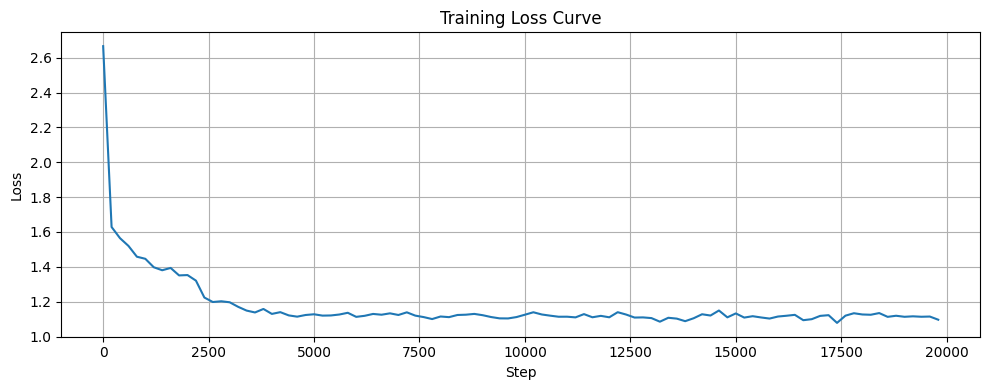

In [18]:
steps, losses = zip(*loss_history)

plt.figure(figsize=(10, 4))
plt.plot(steps, losses)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.tight_layout()
plt.show()

---

# Milestone 4 — Autoregressive Generation

## Goal

Generate text one token at a time.

The model should complete:

```text
12+35=
```

with:

```text
47
```

---

# Step 1 — Generation Function

In [19]:
@torch.no_grad()
def generate(model, start_text, max_new_tokens=10, temperature=1.0):

    model.eval()

    # Encode input
    idx = torch.tensor([encode(start_text)], dtype=torch.long).to(device)

    for _ in range(max_new_tokens):

        # Crop context window
        idx_cond = idx[:, -block_size:]

        # Forward pass
        logits, _ = model(idx_cond)

        # Take last token logits
        logits = logits[:, -1, :]

        # Apply temperature
        logits = logits / temperature

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)

        # TODO:
        # Sample next token using torch.multinomial
        idx_next = torch.multinomial(probs, num_samples=1)

        # TODO:
        # Append prediction to sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return decode(idx[0].tolist())

---

# Step 2 — Test Generation

In [20]:
print(generate(model, '12+35='))
print(generate(model, '99+18='))
print(generate(model, '384+217='))

12+35=47
8+83=91
99+18=117
53+29=
384+217=58
31+79=1


In [ ]:
# Example completions from the trained transformer
# A mix of fixed edge cases plus randomly sampled problems.

fixed_examples = [
    '0+0=',
    '7+8=',
    '12+35=',
    '50+50=',
    '99+1=',
    '99+99=',
    '384+217=',   # 3-digit (unseen during 2-digit training)
]

# Add a batch of randomly sampled 2-digit problems
random_examples = [f'{random.randint(0, 99)}+{random.randint(0, 99)}=' for _ in range(20)]

examples = fixed_examples + random_examples

correct = 0
for prompt in examples:
    out = generate(model, prompt, max_new_tokens=6, temperature=0.1)
    first_line = out.split('\n')[0]          # trim spillover into the next problem
    a, b = prompt[:-1].split('+')
    expected = int(a) + int(b)
    predicted = first_line.split('=')[-1]
    ok = predicted == str(expected)
    correct += ok
    mark = 'OK ' if ok else 'XX '
    print(f"{mark}{first_line:<16} (expected {expected})")

print(f"\n{correct}/{len(examples)} correct")

---

# Final Evaluation Milestone

## Goal

Achieve:

- >=95% accuracy on unseen 2-digit problems
OR
- >=95% accuracy on unseen 3-digit problems

---

# Mathematical Evaluation

This evaluation checks REAL arithmetic correctness.

The model only passes if:

1. Output parses correctly
2. Prediction equals actual sum

---

# Student Task

Complete all TODO sections.

Then run the evaluation block below.

---

# Self-Grading Block

In [21]:
import re


def extract_answer(text):

    # Extract digits after '='
    match = re.search(r'=([0-9]+)', text)

    if match:
        return match.group(1)

    return None


@torch.no_grad()
def evaluate_model(model, num_tests=200, max_digits=2):

    model.eval()

    correct = 0

    examples = []

    for _ in range(num_tests):

        a = random.randint(0, 10**max_digits - 1)
        b = random.randint(0, 10**max_digits - 1)

        prompt = f'{a}+{b}='

        generated = generate(
            model,
            prompt,
            max_new_tokens=max_digits + 3,
            temperature=0.1
        )

        predicted = extract_answer(generated)

        expected = str(a + b)

        is_correct = predicted == expected

        if is_correct:
            correct += 1

        examples.append({
            'prompt': prompt,
            'prediction': predicted,
            'expected': expected,
            'correct': is_correct
        })

    accuracy = correct / num_tests

    return accuracy, examples


# =====================================================
# SELF-GRADING CHECKLIST
# =====================================================

score = 0
max_score = 100

print('\n===============================')
print('AUTOGRADER RESULTS')
print('===============================\n')

# -----------------------------------------------------
# CHECK 1 — Tokenizer
# -----------------------------------------------------

try:
    encoded = encode('12+7=19')
    decoded = decode(encoded)

    if decoded == '12+7=19':
        print('[PASS] Tokenizer encode/decode works')
        score += 15
    else:
        print('[FAIL] Tokenizer mismatch')

except Exception as e:
    print('[FAIL] Tokenizer crashed:', e)


# -----------------------------------------------------
# CHECK 2 — Batch Generation
# -----------------------------------------------------

try:
    X, Y = get_batch()

    if X.shape == Y.shape:
        print('[PASS] Batch generation works')
        score += 15
    else:
        print('[FAIL] Batch shapes incorrect')

except Exception as e:
    print('[FAIL] Batch generation crashed:', e)


# -----------------------------------------------------
# CHECK 3 — Attention Layer
# -----------------------------------------------------

try:
    test_head = Head(16).to(device)

    x = torch.randn(4, block_size, 64).to(device)

    out = test_head(x)

    if out.shape[0] == 4:
        print('[PASS] Attention head runs')
        score += 20
    else:
        print('[FAIL] Attention output incorrect')

except Exception as e:
    print('[FAIL] Attention layer crashed:', e)


# -----------------------------------------------------
# CHECK 4 — Model Forward Pass
# -----------------------------------------------------

try:
    xb, yb = get_batch()

    logits, loss = model(xb, yb)

    if logits.shape[0] == xb.shape[0]:
        print('[PASS] Model forward pass works')
        score += 20
    else:
        print('[FAIL] Model logits incorrect')

except Exception as e:
    print('[FAIL] Model forward pass crashed:', e)


# -----------------------------------------------------
# CHECK 5 — Arithmetic Accuracy
# -----------------------------------------------------

try:
    accuracy, examples = evaluate_model(
        model,
        num_tests=100,
        max_digits=2
    )

    print(f'\n2-digit accuracy: {accuracy:.2%}')

    if accuracy >= 0.95:
        print('[PASS] Achieved >=95% accuracy')
        score += 30
    else:
        print('[FAIL] Accuracy below 95%')

    print('\nExample predictions:\n')

    for ex in examples[:10]:
        print(ex)

except Exception as e:
    print('[FAIL] Evaluation crashed:', e)


# =====================================================
# FINAL SCORE
# =====================================================

print('\n===============================')
print(f'FINAL SCORE: {score}/{max_score}')
print('===============================\n')

if score == 100:
    print('Excellent work — your Tiny Transformer learned arithmetic.')
elif score >= 80:
    print('Good job — most Transformer components work correctly.')
else:
    print('Review the TODO sections and debug carefully.')


AUTOGRADER RESULTS

[PASS] Tokenizer encode/decode works
[PASS] Batch generation works
[PASS] Attention head runs
[PASS] Model forward pass works

2-digit accuracy: 92.00%
[FAIL] Accuracy below 95%

Example predictions:

{'prompt': '54+83=', 'prediction': '137', 'expected': '137', 'correct': True}
{'prompt': '35+79=', 'prediction': '114', 'expected': '114', 'correct': True}
{'prompt': '74+41=', 'prediction': '115', 'expected': '115', 'correct': True}
{'prompt': '23+90=', 'prediction': '113', 'expected': '113', 'correct': True}
{'prompt': '24+19=', 'prediction': '43', 'expected': '43', 'correct': True}
{'prompt': '40+25=', 'prediction': '65', 'expected': '65', 'correct': True}
{'prompt': '93+60=', 'prediction': '153', 'expected': '153', 'correct': True}
{'prompt': '60+82=', 'prediction': '142', 'expected': '142', 'correct': True}
{'prompt': '37+99=', 'prediction': '136', 'expected': '136', 'correct': True}
{'prompt': '23+20=', 'prediction': '43', 'expected': '43', 'correct': True}

FIN

---

# Stretch Goals

If you finish early:

1. Add dropout
2. Add learning-rate scheduling
3. Train on subtraction
4. Add multiplication
5. Compare greedy decoding vs sampling
6. Visualize attention maps
7. Train on 4-digit addition
8. Add teacher forcing experiments
9. Implement KV caching
10. Compare parameter counts vs accuracy

---

# Suggested Hyperparameters

These are known-good starter values:

In [22]:
batch_size = 32
block_size = 32
n_embd = 64
n_head = 4
n_layer = 2
learning_rate = 1e-3
max_iters = 3000

---

# Submission Requirements

Submit:

1. Completed notebook
2. Final autograder score
3. Screenshot of generated examples
4. Short explanation:
   - What was hardest?
   - What debugging strategy worked best?
   - What surprised you about Transformers?

---

# Important Conceptual Questions

You should be able to explain:

1. Why is the causal mask necessary?
2. Why do we shift targets by one token?
3. Why do we add positional embeddings?
4. Why do residual connections help?
5. Why does the model eventually learn carrying operations?
6. Why is addition a sequence modeling problem?
7. What happens if the block size is too small?

---

# Recommended Debugging Strategy

1. First verify tokenizer correctness
2. Then verify batches
3. Then verify attention dimensions
4. Then verify loss decreases
5. Finally test arithmetic correctness

Do not attempt to debug the full model all at once.

---

# Expected Results

Typical training progression:

```text
step 0     loss ~2.5
step 500   loss ~1.2
step 1500  loss ~0.4
step 3000  loss ~0.1
```

Final 2-digit accuracy:

```text
95% - 100%
```

---

# Final Reflection

This assignment demonstrates a profound idea:

A Transformer trained only on next-character prediction can learn an algorithmic process like arithmetic.

No calculator rules were explicitly programmed.

The model discovers the structure of addition from examples.